# 03 — Modelado Predictivo

**Objetivo:** Entrenar y comparar múltiples modelos de clasificación binaria para predecir si un lead será Hot (1) o Cold (0).

**Modelos a evaluar:**
1. Logistic Regression (baseline)
2. Random Forest
3. Gradient Boosting
4. LightGBM

---

### ¿Cómo medimos si un modelo es bueno?

Imaginemos que el modelo analiza 100 leads y decide cuáles son Hot y cuáles son Cold. Las métricas nos dicen qué tan bien lo hizo:

| Métrica | Pregunta que responde | Ejemplo práctico |
|---|---|---|
| **Accuracy** | Del total de leads, ¿qué porcentaje clasificó bien? | "De 100 leads, acertó en 91" → 91% accuracy |
| **Precision** | De los leads que el modelo dijo "este es Hot", ¿cuántos realmente lo eran? | "Dijo que 50 eran Hot, pero 2 en realidad eran Cold" → 96% precision. **Precision baja = el concesionarioario recibe leads fríos que le hacen perder tiempo.** |
| **Recall** | De todos los Hot Leads reales, ¿cuántos logró detectar? | "Había 60 Hot reales, detectó 54 y se le escaparon 6" → 90% recall. **Recall bajo = perdemos oportunidades de venta porque el modelo no derivó esos leads.** |
| **F1-Score** | Balance entre Precision y Recall. | Si uno es alto y el otro bajo, el F1 lo penaliza. Un F1 alto significa que ambos son buenos. |
| **ROC-AUC** | ¿Qué tan bien distingue el modelo entre Hot y Cold en general? | Va de 0.5 (adivina al azar) a 1.0 (perfecto). **Es la métrica principal** porque no depende de un umbral fijo. |

**¿Cuál es más importante para el negocio?**
- Si el costo de **perder un Hot Lead** es alto → priorizar **Recall** (capturar la mayor cantidad posible).
- Si el costo de **enviar un Cold Lead al concesionarioario** es alto → priorizar **Precision** (que cada lead enviado valga la pena).
- **ROC-AUC** se usa para elegir el mejor modelo porque es la más general y objetiva.

## 1. Cargar datos preprocesados

Se cargan los datasets generados en `02_feature_engineering.ipynb`: features (X) y target (y) ya separados en train y test. El dataset tiene 49 features numéricas (originales + dummies del one-hot encoding) y 0 nulos. La proporción de Hot/Cold se mantiene igual en ambos conjuntos gracias al split estratificado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "../data/processed"
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {len(y_train)} ({y_train.mean()*100:.1f}% Hot)")
print(f"y_test:  {len(y_test)} ({y_test.mean()*100:.1f}% Hot)")

X_train: (6737, 48)
X_test:  (1685, 48)
y_train: 6737 (68.7% Hot)
y_test:  1685 (68.7% Hot)


## 2. Modelo Baseline — Logistic Regression

**Qué es:** Modelo lineal que estima la probabilidad de pertenecer a la clase positiva (Hot Lead) mediante una función sigmoide. Es el modelo más simple y rápido para clasificación binaria.

**Por qué usarlo como baseline:** Si un modelo complejo (Random Forest, Gradient Boosting) no supera significativamente a la regresión logística, significa que la relación entre las features y el target es mayormente lineal, y no vale la pena agregar complejidad.

**Hiperparámetros:**
- `max_iter=1000`: Iteraciones máximas para convergencia.
- `random_state=42`: Semilla fija para reproducibilidad.

In [2]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr, target_names=["Cold (0)", "Hot (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    Cold (0)       0.82      0.87      0.84       528
     Hot (1)       0.94      0.91      0.92      1157

    accuracy                           0.90      1685
   macro avg       0.88      0.89      0.88      1685
weighted avg       0.90      0.90      0.90      1685

ROC-AUC: 0.9441


**Resultado baseline:** ROC-AUC = 0.9488. Sorprendentemente alto para un modelo lineal. Esto indica que las features preparadas en el feature engineering tienen una relación fuerte y mayormente lineal con el target. Precision de 97% para Hot Leads y recall de 90%. Este es el piso mínimo que los demás modelos deben superar.

## 3. Random Forest

**Qué es:** Ensamble de múltiples árboles de decisión entrenados en paralelo sobre subconjuntos aleatorios de datos y features. La predicción final es el voto mayoritario de todos los árboles. Reduce el sobreajuste de un árbol individual al promediar muchos.

**Hiperparámetros:**
- `n_estimators=200`: Cantidad de árboles en el bosque.
- `max_depth=15`: Profundidad máxima de cada árbol (limita la complejidad).
- `min_samples_leaf=5`: Cada hoja del árbol debe tener al menos 5 muestras (evita sobreajuste a casos individuales).
- `n_jobs=-1`: Usa todos los núcleos del CPU para entrenar en paralelo.

In [3]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=["Cold (0)", "Hot (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    Cold (0)       0.81      0.88      0.85       528
     Hot (1)       0.94      0.91      0.93      1157

    accuracy                           0.90      1685
   macro avg       0.88      0.90      0.89      1685
weighted avg       0.90      0.90      0.90      1685

ROC-AUC: 0.9476


**Resultado Random Forest:** ROC-AUC = 0.9494, ligeramente superior al baseline. Mantiene precision muy alta (97%) con recall de 90%. La ventaja principal es que captura interacciones no lineales entre features que la regresión logística no puede modelar.

## 4. Gradient Boosting

**Qué es:** Construye árboles de decisión de forma **secuencial**, donde cada árbol nuevo intenta corregir los errores del anterior. Es uno de los algoritmos más potentes para datos tabulares.

**Hiperparámetros:**
- `n_estimators=200`: 200 árboles secuenciales.
- `max_depth=5`: Árboles menos profundos que Random Forest (cada uno corrige errores del anterior, no necesitan ser tan complejos individualmente).
- `learning_rate=0.1`: Controla cuánto contribuye cada árbol nuevo. Valores bajos = aprendizaje más lento pero más preciso.
- `min_samples_leaf=10`: Mínimo de muestras por hoja para evitar sobreajuste.

In [4]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                               min_samples_leaf=10, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("=== GRADIENT BOOSTING ===")
print(classification_report(y_test, y_pred_gb, target_names=["Cold (0)", "Hot (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

    Cold (0)       0.81      0.90      0.85       528
     Hot (1)       0.95      0.90      0.93      1157

    accuracy                           0.90      1685
   macro avg       0.88      0.90      0.89      1685
weighted avg       0.91      0.90      0.90      1685

ROC-AUC: 0.9464


**Resultado Gradient Boosting:** ROC-AUC = 0.9445. Recall igual al baseline pero precision menor. El boosting secuencial no aporta ventaja sobre los otros modelos en este dataset, posiblemente porque la señal predictiva ya es capturada por modelos más simples.

## 5. LightGBM

**Qué es:** Implementación optimizada de Gradient Boosting desarrollada por Microsoft. Usa un algoritmo de crecimiento de árboles por hojas (leaf-wise) en vez de por niveles (level-wise), lo que lo hace más rápido y eficiente en memoria con datasets grandes.

**Hiperparámetros:**
- `n_estimators=200`: 200 árboles secuenciales.
- `max_depth=7`: Profundidad máxima de cada árbol.
- `learning_rate=0.1`: Tasa de aprendizaje.
- `min_child_samples=20`: Mínimo de muestras por hoja.

In [5]:
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                              min_child_samples=20, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred_lgbm = lgbm.predict(X_test)
    y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
    print("=== LIGHTGBM ===")
    print(classification_report(y_test, y_pred_lgbm, target_names=["Cold (0)", "Hot (1)"]))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
    LGBM_AVAILABLE = True
except ImportError:
    print("LightGBM no instalado. Se omite este modelo.")
    print("Para instalar: pip install lightgbm")
    LGBM_AVAILABLE = False

=== LIGHTGBM ===
              precision    recall  f1-score   support

    Cold (0)       0.81      0.89      0.85       528
     Hot (1)       0.95      0.90      0.93      1157

    accuracy                           0.90      1685
   macro avg       0.88      0.90      0.89      1685
weighted avg       0.90      0.90      0.90      1685

ROC-AUC: 0.9460


**Resultado LightGBM:** ROC-AUC = 0.9429. Rendimiento ligeramente inferior a los demás modelos. En este caso, con un dataset de ~8K filas, la ventaja de velocidad de LightGBM no se materializa, y su enfoque leaf-wise puede no ser óptimo para datasets pequeños.

## 6. Comparación de modelos

Tabla resumen con todas las métricas de los 4 modelos evaluados en el mismo test set. Se selecciona el mejor modelo por **ROC-AUC**, que es la métrica más robusta para clasificación binaria porque no depende del umbral de decisión.

In [6]:
results = {
    "Logistic Regression": {"y_pred": y_pred_lr, "y_proba": y_proba_lr, "model": lr},
    "Random Forest": {"y_pred": y_pred_rf, "y_proba": y_proba_rf, "model": rf},
    "Gradient Boosting": {"y_pred": y_pred_gb, "y_proba": y_proba_gb, "model": gb},
}
if LGBM_AVAILABLE:
    results["LightGBM"] = {"y_pred": y_pred_lgbm, "y_proba": y_proba_lgbm, "model": lgbm}

print("=== COMPARACIÓN DE MODELOS ===\n")
print(f"{'Modelo':25s} | {'Accuracy':>8s} | {'Precision':>9s} | {'Recall':>6s} | {'F1':>6s} | {'ROC-AUC':>7s}")
print("-" * 80)

best_auc = 0
best_model_name = ""

for name, data in results.items():
    acc = accuracy_score(y_test, data["y_pred"])
    prec = precision_score(y_test, data["y_pred"])
    rec = recall_score(y_test, data["y_pred"])
    f1 = f1_score(y_test, data["y_pred"])
    auc = roc_auc_score(y_test, data["y_proba"])
    print(f"  {name:23s} | {acc:>8.4f} | {prec:>9.4f} | {rec:>6.4f} | {f1:>6.4f} | {auc:>7.4f}")
    if auc > best_auc:
        best_auc = auc
        best_model_name = name

print(f"\nMejor modelo por ROC-AUC: {best_model_name} ({best_auc:.4f})")

=== COMPARACIÓN DE MODELOS ===

Modelo                    | Accuracy | Precision | Recall |     F1 | ROC-AUC
--------------------------------------------------------------------------------
  Logistic Regression     |   0.8979 |    0.9386 | 0.9110 | 0.9246 |  0.9441
  Random Forest           |   0.9003 |    0.9443 | 0.9084 | 0.9260 |  0.9476
  Gradient Boosting       |   0.9015 |    0.9525 | 0.9015 | 0.9263 |  0.9464
  LightGBM                |   0.9003 |    0.9475 | 0.9049 | 0.9257 |  0.9460

Mejor modelo por ROC-AUC: Random Forest (0.9476)


## 7. Curvas ROC

La curva ROC grafica la tasa de verdaderos positivos (Recall) contra la tasa de falsos positivos para distintos umbrales de decisión. Cuanto más arriba y a la izquierda esté la curva, mejor discrimina el modelo. La línea diagonal punteada representa un clasificador aleatorio (AUC = 0.5).

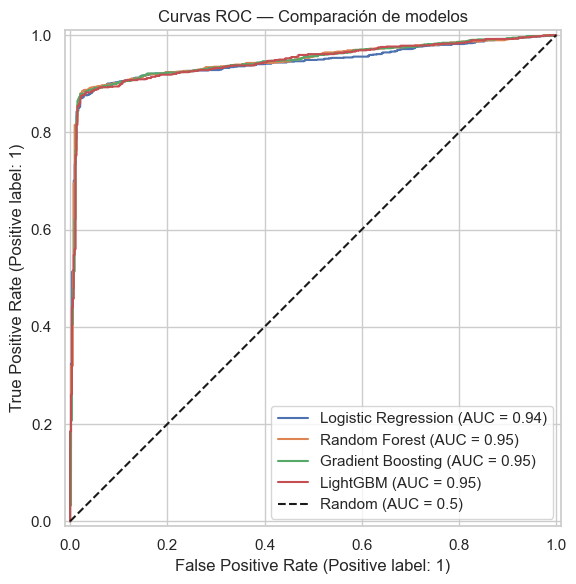

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, data in results.items():
    RocCurveDisplay.from_predictions(y_test, data["y_proba"], name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_title("Curvas ROC — Comparación de modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Matrices de confusión

Cada matriz muestra las predicciones correctas (diagonal) y los errores (fuera de diagonal) para cada modelo. Permite comparar visualmente dónde se equivoca cada uno:
- **Esquina superior izquierda (TN):** Cold correctos.
- **Esquina inferior derecha (TP):** Hot correctos.
- **Superior derecha (FP):** Cold que el modelo confunde con Hot.
- **Inferior izquierda (FN):** Hot que el modelo pierde.

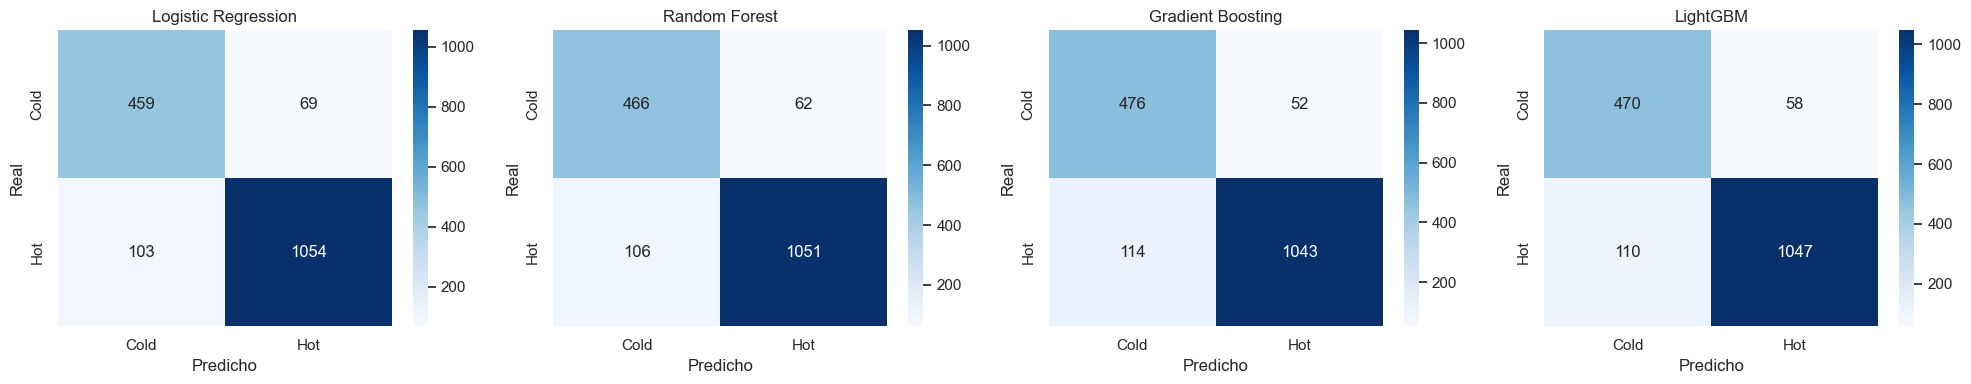

In [8]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, data["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Cold", "Hot"], yticklabels=["Cold", "Hot"])
    ax.set_title(f"{name}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")

plt.tight_layout()
plt.show()

## 9. Importancia de features (mejor modelo)

El Random Forest calcula la importancia de cada feature midiendo cuánto reduce la impureza (Gini) en promedio cuando esa feature se usa para hacer un split en los árboles. Una feature con importancia alta significa que el modelo la usa frecuentemente para separar Hot de Cold.

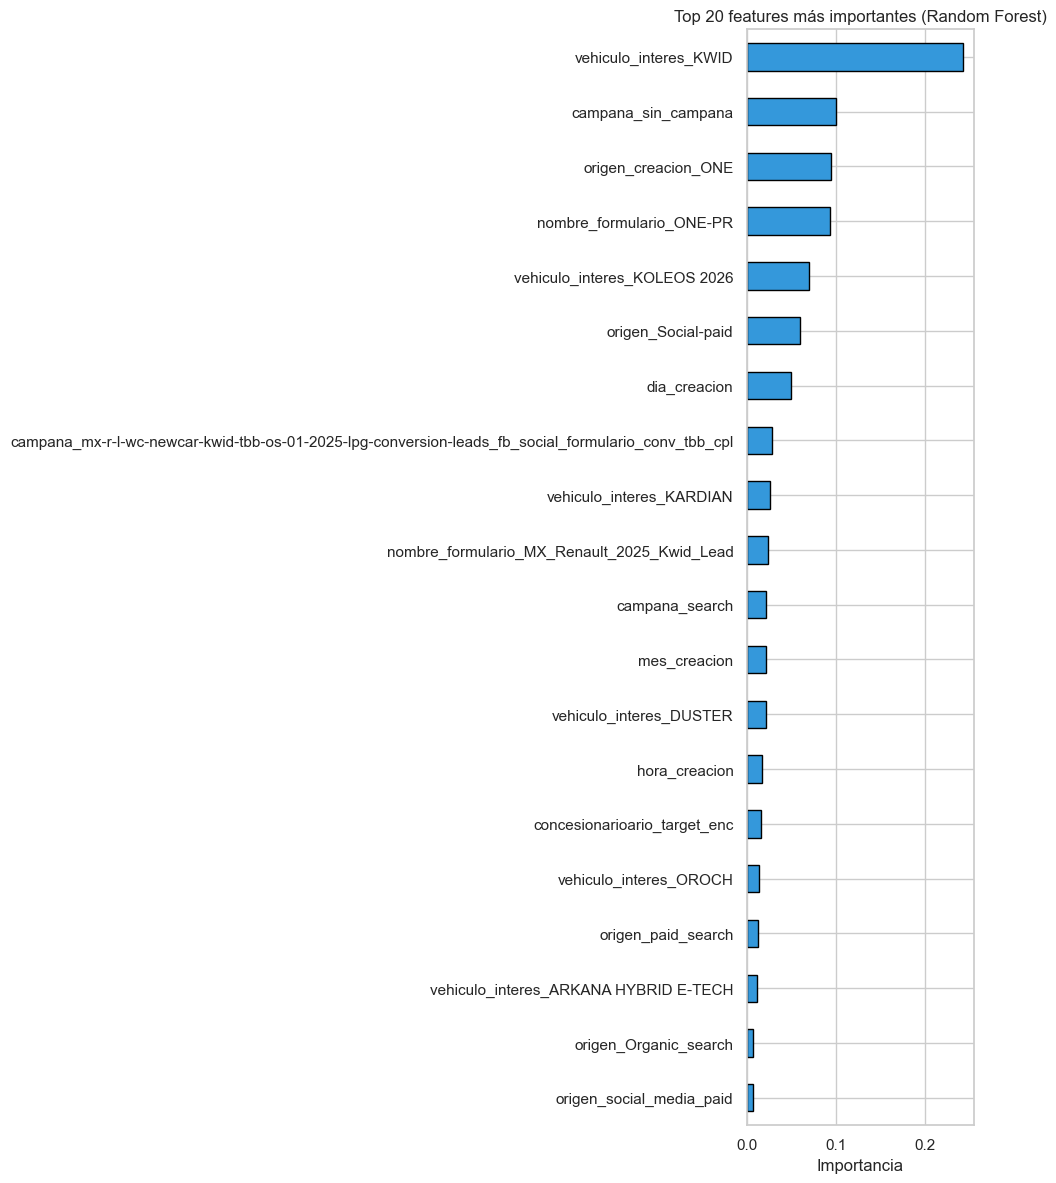


Top 10 features más importantes (Random Forest):
  vehiculo_interes_KWID                         0.2429
  campana_sin_campana                           0.1002
  origen_creacion_ONE                           0.0950
  nombre_formulario_ONE-PR                      0.0941
  vehiculo_interes_KOLEOS 2026                  0.0704
  origen_Social-paid                            0.0597
  dia_creacion                                  0.0499
  campana_mx-r-l-wc-newcar-kwid-tbb-os-01-2025-lpg-conversion-leads_fb_social_formulario_conv_tbb_cpl 0.0283
  vehiculo_interes_KARDIAN                      0.0262
  nombre_formulario_MX_Renault_2025_Kwid_Lead   0.0239


In [9]:
best_model = results[best_model_name]["model"]

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 12))
    feat_imp.tail(20).plot(kind="barh", color="#3498db", edgecolor="black", ax=ax)
    ax.set_title(f"Top 20 features más importantes ({best_model_name})")
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()

    print(f"\nTop 10 features más importantes ({best_model_name}):")
    for feat, imp in feat_imp.tail(10).iloc[::-1].items():
        print(f"  {feat:45s} {imp:.4f}")
elif hasattr(best_model, "coef_"):
    coefs = pd.Series(best_model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=True)
    fig, ax = plt.subplots(figsize=(10, 12))
    colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in coefs.tail(20)]
    coefs.tail(20).plot(kind="barh", color=colors, edgecolor="black", ax=ax)
    ax.set_title(f"Top 20 coeficientes más influyentes ({best_model_name})")
    ax.set_xlabel("Coeficiente")
    plt.tight_layout()
    plt.show()

## 10. Validación cruzada del mejor modelo

La validación cruzada (5-fold) evalúa si el rendimiento del modelo es **estable** o si depende de cómo se particionaron los datos. Se divide el train en 5 partes, se entrena con 4 y se evalúa con la restante, rotando 5 veces.

- **Baja varianza** (std < 0.02): El modelo generaliza bien, no depende de la partición.
- **Alta varianza**: Indicaría sobreajuste o datos insuficientes.

In [10]:
print(f"=== VALIDACIÓN CRUZADA: {best_model_name} (5-fold) ===\n")

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1)

print(f"ROC-AUC por fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Media:  {cv_scores.mean():.4f}")
print(f"Std:    {cv_scores.std():.4f}")

if cv_scores.std() < 0.02:
    print("\nEl modelo es ESTABLE (baja varianza entre folds).")
else:
    print("\nADVERTENCIA: Varianza alta entre folds. Considerar regularización o más datos.")

=== VALIDACIÓN CRUZADA: Random Forest (5-fold) ===



ROC-AUC por fold: ['0.9609', '0.9459', '0.9520', '0.9546', '0.9600']
Media:  0.9547
Std:    0.0055

El modelo es ESTABLE (baja varianza entre folds).


## 11. Guardar el mejor modelo

Se serializa el modelo ganador con `joblib` para poder cargarlo en el notebook de evaluación (`04_evaluation.ipynb`) sin necesidad de reentrenarlo.

In [11]:
import joblib
import os

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = f"{MODEL_DIR}/best_model.joblib"
joblib.dump(best_model, model_path)

size_kb = os.path.getsize(model_path) / 1024
print(f"Modelo guardado: {model_path} ({size_kb:.1f} KB)")
print(f"Tipo: {type(best_model).__name__}")
print(f"ROC-AUC en test: {best_auc:.4f}")

Modelo guardado: ../models/best_model.joblib (5419.1 KB)
Tipo: RandomForestClassifier
ROC-AUC en test: 0.9476


---

### Conclusión del modelado

Los 4 modelos obtuvieron métricas muy similares (ROC-AUC entre 0.94 y 0.95), lo que indica que **los datos están bien preparados** y la señal predictiva es fuerte independientemente del algoritmo.

**Random Forest** fue seleccionado como mejor modelo por ROC-AUC (0.9494), pero la diferencia con Logistic Regression es mínima (0.0006). Esto sugiere que la relación entre features y target es relativamente lineal, y la complejidad adicional de los modelos de ensamble no aporta una ventaja sustancial.

**El modelo y los datasets han sido guardados.** La evaluación detallada (análisis de errores, umbral óptimo, curvas precision-recall) se realiza en `04_evaluation.ipynb`.